Feature Importance and Selection for Soil Moisture Model
--------------------------------------------------------

This notebook generates multiple feature importance scores, ranks the features
and automatically suggests a feature selection based on the majority vote of all models.

The model training data is based on soil moisture data and multiple covariates.

The following six models for feature importance scoring are included:
- Spearman rank analysis (see 'selectio.models.spearman')
- Correlation coefficient significance of linear/log-scaled Bayesian Linear Regression (see 'selectio.models.blr')
- Random Forest Permutation test (see 'selectio.models.rf.py')
- Random Decision Trees on various subsamples of data (see 'selectio.models.rdt.py')
- Mutual Information Regression (see 'selectio.models.mi')
- General correlation coefficients (see 'selectio.models.xicor')

This notebook generate synthetic test data but can be used with any tabulated data or dataframes.

User settings, such as input/output paths and all other options, are set in the settings file 
(Default filename: settings_featureimportance.yaml) 
Alternatively, the settings file can be specified as a command line argument with: 
'-s', or '--settings' followed by PATH-TO-FILE/FILENAME.yaml 
(e.g. python featureimportance.py -s settings_featureimportance.yaml).

Requirements:
- selectio
- matplotlib
- pyyaml
- pandas

This package is part of the machine learning project developed for the Agricultural Research Federation (AgReFed).



### Library imports

In [1]:
# Import libraries
import os 
import yaml
import shutil
import numpy as np
import pandas as pd
import importlib
import pkg_resources
import matplotlib.pyplot as plt
from matplotlib.image import imread
# Import selection package
from selectio import selectio
from selectio.simdata import create_simulated_features
from selectio.utils import plot_correlationbar, plot_feature_correlation_spearman, gradientbars

plt.rcParams['figure.dpi'] = 50

C:\Users\Yuxi\AppData\Local\Temp\ipykernel_10244\889347253.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Define output directory

In [2]:
# Generate result folder and name of settings file to save configuration
target = "SM"
outpath = f'./results_fsel'
os.makedirs(outpath, exist_ok = True)
fname_settings = f'settings_fsel.yaml'

### Reading data

Here we read-in soil moisture data and covariates into pandas dataframe.

In [3]:
# This function generates simulated data with added noise 
# and automatically saves data and coefficients in output directory as csv files
inpath = "../dataset/"
infname = "dataset.csv"
df = pd.read_csv(os.path.join(inpath, infname))

# print generated dataframe header 
print('')
print('Dataframe header extract: ')
df.head()


Dataframe header extract: 


,Date,SiteID,DepthTop,DepthBot,SM,BDW,CLY,SND,SLT,SOC,...,Slope,TWI,Total,K,T,U,Northing,Easting,Day,Week
0,2002-01-01,Adelong_2,0,30,0.063910,1.160000,17.666667,65.333333,17.0,3.066667,...,6.04,7.96,34.01,0.63,7.12,1.40,6078901.79,602757.75,731,104
1,2002-01-01,Adelong_2,30,60,0.302002,1.370000,32.000000,52.000000,16.0,0.710000,...,6.04,7.96,34.01,0.63,7.12,1.40,6078901.79,602757.75,731,104
2,2002-01-01,Adelong_2,60,90,0.275485,1.410000,36.000000,48.000000,15.0,0.490000,...,6.04,7.96,34.01,0.63,7.12,1.40,6078901.79,602757.75,731,104
3,2002-01-01,Adelong_3,0,5,0.104612,1.170000,16.000000,67.000000,17.0,4.310000,...,12.99,5.48,22.75,0.42,4.93,0.88,6082039.07,599978.17,731,104
4,2002-01-01,Adelong_3,0,30,0.124387,1.261667,17.666667,65.333333,17.0,3.301667,...,12.99,5.48,22.75,0.42,4.93,0.88,6082039.07,599978.17,731,104


In [4]:
df.columns

Index(['Date', 'SiteID', 'DepthTop', 'DepthBot', 'SM', 'BDW', 'CLY', 'SND',
       'SLT', 'SOC', 'DUL', 'L15', 'PAWC', 'ET', 'ET_df_500', 'ET_df_700',
       'ET_df_900', 'ET_df_950', 'ET_df_990', 'ET_df_999', 'Rain',
       'Rain_df_500', 'Rain_df_700', 'Rain_df_900', 'Rain_df_950',
       'Rain_df_990', 'Rain_df_999', 'Solar', 'NDVI', 'Latitude', 'Longitude',
       'DEM', 'Slope', 'TWI', 'Total', 'K', 'T', 'U', 'Northing', 'Easting',
       'Day', 'Week'],
      dtype='object')

In [5]:
feature_names = df.columns.drop(['Date', 'SiteID', 'Day', 'Week', 'SM', 'SLT', 'DUL',
                                 'Easting', 'Northing', 'Longitude', 'Latitude', ]).tolist()
feature_names

['DepthTop',
 'DepthBot',
 'BDW',
 'CLY',
 'SND',
 'SOC',
 'L15',
 'PAWC',
 'ET',
 'ET_df_500',
 'ET_df_700',
 'ET_df_900',
 'ET_df_950',
 'ET_df_990',
 'ET_df_999',
 'Rain',
 'Rain_df_500',
 'Rain_df_700',
 'Rain_df_900',
 'Rain_df_950',
 'Rain_df_990',
 'Rain_df_999',
 'Solar',
 'NDVI',
 'DEM',
 'Slope',
 'TWI',
 'Total',
 'K',
 'T',
 'U']

### A) Generate Settings YAML file

This is an example of how to generate a settings file from a template and to populate with custom settings.

In [6]:
# define settings name
# generate settings template
shutil.copyfile(selectio._fname_settings, os.path.join(outpath, fname_settings))
with open(os.path.join(outpath, fname_settings), 'r') as f:
    settings = yaml.load(f, Loader=yaml.FullLoader)
settings['name_features'] = feature_names
settings['name_target'] = target
settings['infname'] = infname
settings['inpath'] = inpath
settings['outpath'] = outpath
settings_path = os.path.join(outpath, fname_settings)
print('Saving settings in: ', settings_path)
with open(settings_path, 'w') as f:
    yaml.dump(settings, f)

print('Settings:')
[print(f'{keys}: {values}') for keys, values in settings.items()]

Saving settings in:  ./results_fsel\settings_fsel.yaml
Settings:
inpath: ../dataset/
infname: dataset.csv
outpath: ./results_fsel
name_target: SM
name_features: ['DepthTop', 'DepthBot', 'BDW', 'CLY', 'SND', 'SOC', 'L15', 'PAWC', 'ET', 'ET_df_500', 'ET_df_700', 'ET_df_900', 'ET_df_950', 'ET_df_990', 'ET_df_999', 'Rain', 'Rain_df_500', 'Rain_df_700', 'Rain_df_900', 'Rain_df_950', 'Rain_df_990', 'Rain_df_999', 'Solar', 'NDVI', 'DEM', 'Slope', 'TWI', 'Total', 'K', 'T', 'U']


[None, None, None, None, None]

### B) Run automatic feature selection and plotting

In [7]:
# Run selectio main
selectio.main(settings_path)

Calculate Spearman correlation matrix...
Computing scores for model spearman...
Done, 17 features selected.
Computing scores for model mi...
Done, 25 features selected.
Computing scores for model xicor...
Done, 21 features selected.
Computing scores for model blr...
Done, 11 features selected.
Computing scores for model rf...
Done, 12 features selected.
Computing scores for model rdt...
Done, 15 features selected.
Feature selection: 
   name_features  score_combined
23          NDVI          0.1164
4            SND          0.0995
3            CLY          0.0941
6            L15          0.0778
2            BDW          0.0728
1       DepthBot          0.0714
5            SOC          0.0634
0       DepthTop          0.0591
7           PAWC          0.0469
19   Rain_df_950          0.0413
20   Rain_df_990          0.0362
21   Rain_df_999          0.0317
14     ET_df_999          0.0272
22         Solar          0.0208
13     ET_df_990          0.0206
18   Rain_df_900          0.0189
1

### C) Read dataframe of computed feature importance scores

In [8]:
dfresults = pd.read_csv(os.path.join(outpath, 'feature-importance_scores.csv'), index_col='Feature_index')
dfresults

,name_features,score_spearman,score_mi,score_xicor,score_blr,score_rf,score_rdt,woe_spearman,woe_mi,woe_xicor,woe_blr,woe_rf,woe_rdt,score_combined,selected
Feature_index,,,,,,,,,,,,,,,
0,DepthTop,0.0734,0.0374,0.0440,0.0672,0.0000,0.1031,1,1,1,1,0,1,0.0591,1
1,DepthBot,0.0768,0.0430,0.0512,0.1018,0.0150,0.1194,1,1,1,1,0,1,0.0714,1
2,BDW,0.0449,0.0802,0.0750,0.1453,0.0336,0.0210,1,1,1,1,1,1,0.0728,1
3,CLY,0.0765,0.0730,0.0658,0.1465,0.0561,0.0992,1,1,1,1,1,1,0.0941,1
4,SND,0.0754,0.0752,0.0631,0.0668,0.2065,0.0597,1,1,1,1,1,1,0.0995,1
5,SOC,0.0641,0.0858,0.0700,0.0212,0.0375,0.0698,1,1,1,1,1,1,0.0634,1
6,L15,0.0800,0.0615,0.0551,0.0000,0.1493,0.0815,1,1,1,0,1,1,0.0778,1
7,PAWC,0.0581,0.0505,0.0555,0.0449,0.0232,0.0255,1,1,1,1,1,1,0.0469,1
8,ET,0.0141,0.0537,0.0310,0.0000,0.0000,0.0080,0,1,1,0,0,0,0.0154,0


In [9]:
# Show selected features only
dfsel = dfresults[dfresults.selected == 1].sort_values('score_combined', ascending=False)

In [10]:
dfsel['name_features'].to_list()

['NDVI',
 'SND',
 'CLY',
 'L15',
 'BDW',
 'DepthBot',
 'SOC',
 'DepthTop',
 'PAWC',
 'Rain_df_950',
 'Rain_df_990',
 'Rain_df_999',
 'ET_df_999',
 'Solar',
 'ET_df_990',
 'Rain_df_900',
 'Rain_df_700']

## Show all output images

In [11]:
# Get all filenames with  .png format from output directory
files = os.listdir(outpath)
pngfiles = [name for name in files if name.endswith('.png')]
print('Image files generated: ', pngfiles)

Image files generated:  ['Combined-feature-importance.png', 'Feature_Correlations_Hierarchical_Spearman.png', 'Feature_importances_all.png', 'Feature_importance_map.png']


### Feature Correlation Cluster

Plot feature correlations using Spearman correlation coefficients. Feature correlations are automatically clustered using hierarchical clustering as shown in dendrogram.

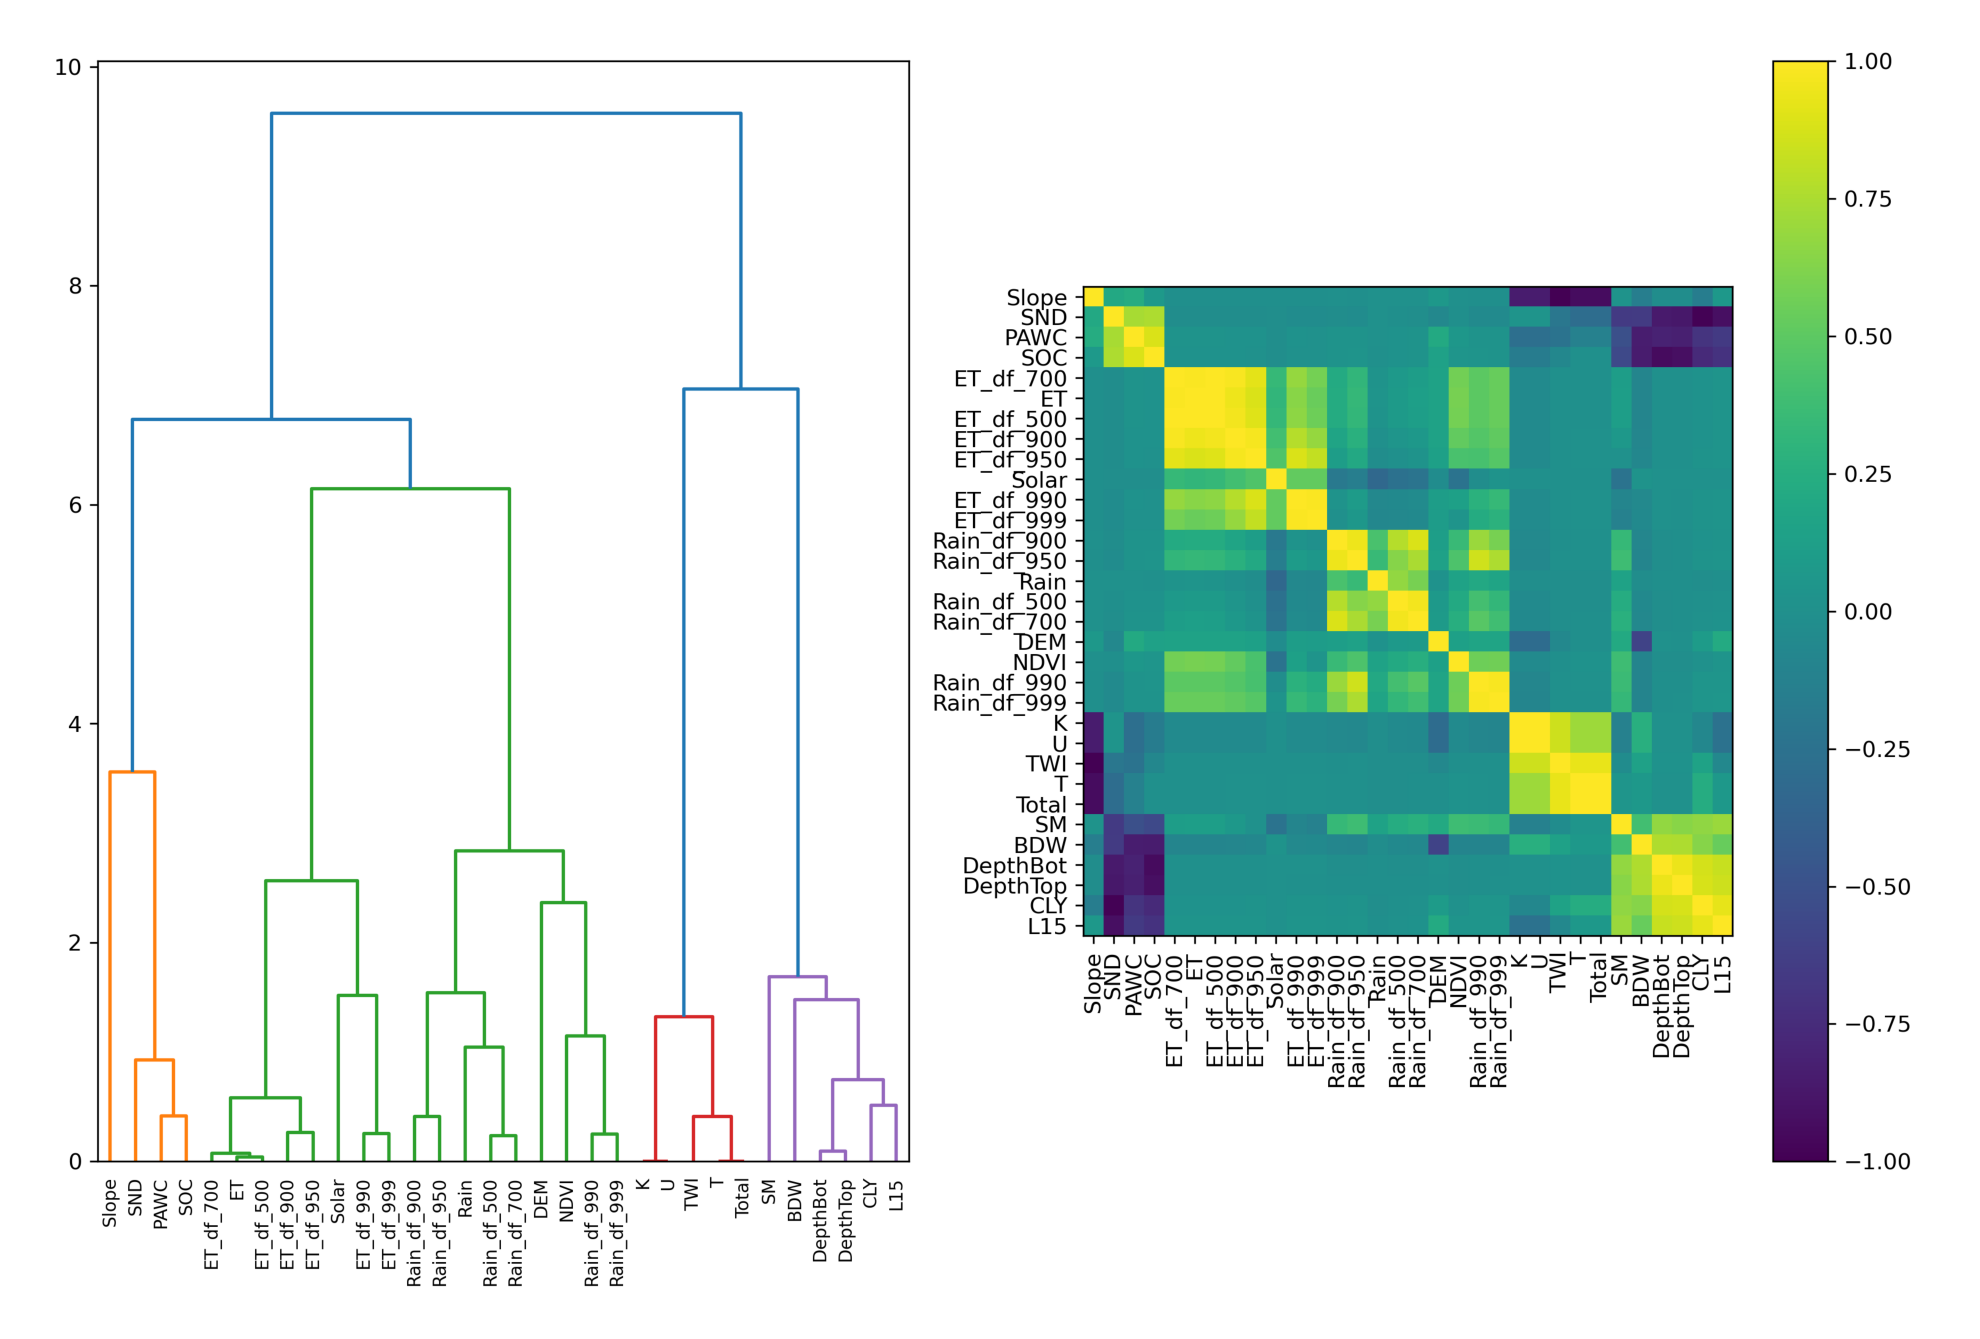

In [12]:
filename = 'Feature_Correlations_Hierarchical_Spearman.png'
img = imread(f"{outpath}/{filename}", format='PNG')
fig = plt.figure(dpi=300)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
plt.imshow(img)

### Plot feature importance scores for each model

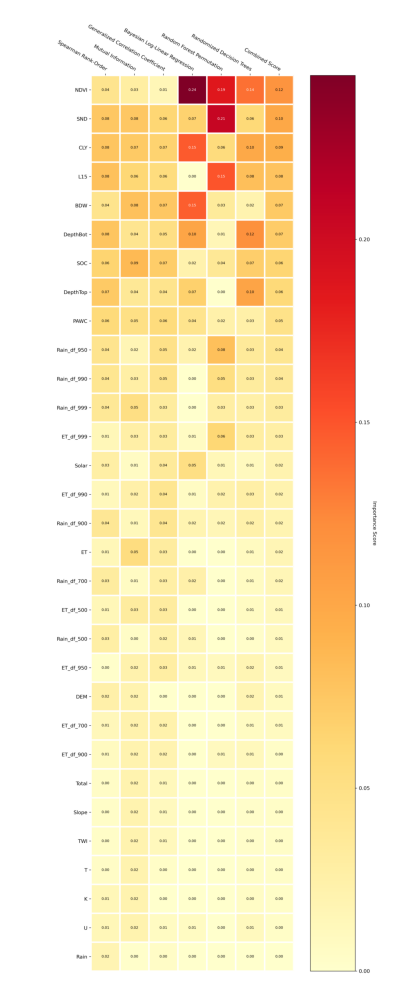

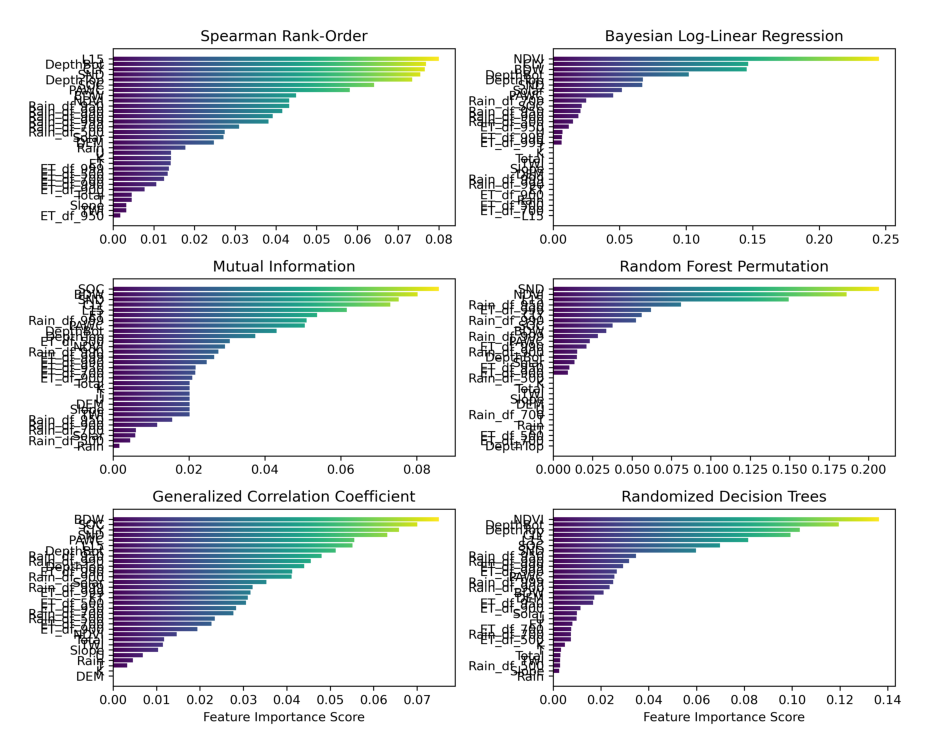

In [13]:
# show importance matrix
filename = 'Feature_importance_map.png'
img = imread(f"{outpath}/{filename}", format='PNG')
fig = plt.figure(dpi=200)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
plt.imshow(img)
plt.show()

# show detailed plots
filename = 'Feature_importances_all.png'
img = imread(f"{outpath}/{filename}", format='PNG')
fig = plt.figure(dpi=150)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
plt.imshow(img)
plt.show()

### Plot combined model importance scores

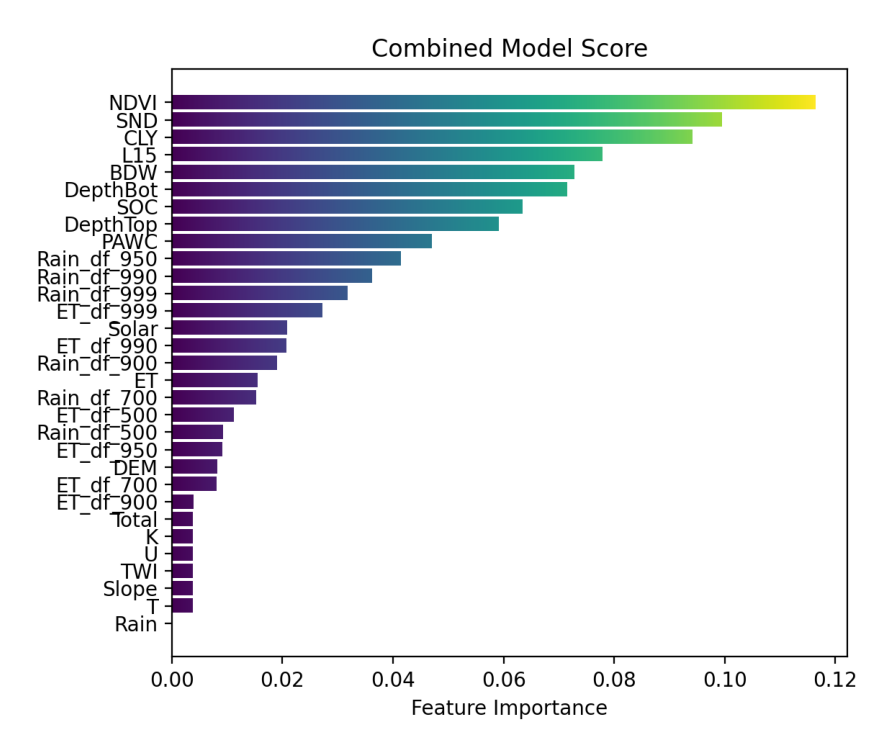

In [14]:
filename = 'Combined-feature-importance.png'
img = imread(f"{outpath}/{filename}", format='PNG')
fig = plt.figure(dpi=150)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
plt.imshow(img)